In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import train

In [17]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df = train.copy()
# 1. Обработка DAYS_EMPLOYED
df['DAYS_EMPLOYED_ANOM'] =(df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# 2. Переводим дни в годы (так понятнее)
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365.25).round(1)
df['EMPLOYED_YEARS'] = (-df['DAYS_EMPLOYED'] / 365.25).round(1)
df['REGISTRATION_YEARS'] = (-df['DAYS_REGISTRATION'] / 365.25).round(1)
df['ID_PUBLISH_YEARS'] = (-df['DAYS_ID_PUBLISH'] / 365.25).round(1)

# 3. Полезные отношения
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
df['CREDIT_ANNUITY_RATIO'] = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + 1)
df['GOODS_CREDIT_RATIO'] = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)

# 4. Проверяем, что получилось
print("AGE_YEARS:")
print(df['AGE_YEARS'].describe().round(1))
print("\nEMPLOYED_YEARS:")
print(df['EMPLOYED_YEARS'].describe().round(1))
print("\nДоля аномалий DAYS_EMPLOYED:", df['DAYS_EMPLOYED_ANOM'].mean().round(3))


AGE_YEARS:
count    307511.0
mean         43.9
std          11.9
min          20.5
25%          34.0
50%          43.1
75%          53.9
max          69.1
Name: AGE_YEARS, dtype: float64

EMPLOYED_YEARS:
count    252137.0
mean          6.5
std           6.4
min          -0.0
25%           2.1
50%           4.5
75%           8.7
max          49.0
Name: EMPLOYED_YEARS, dtype: float64

Доля аномалий DAYS_EMPLOYED: 0.18


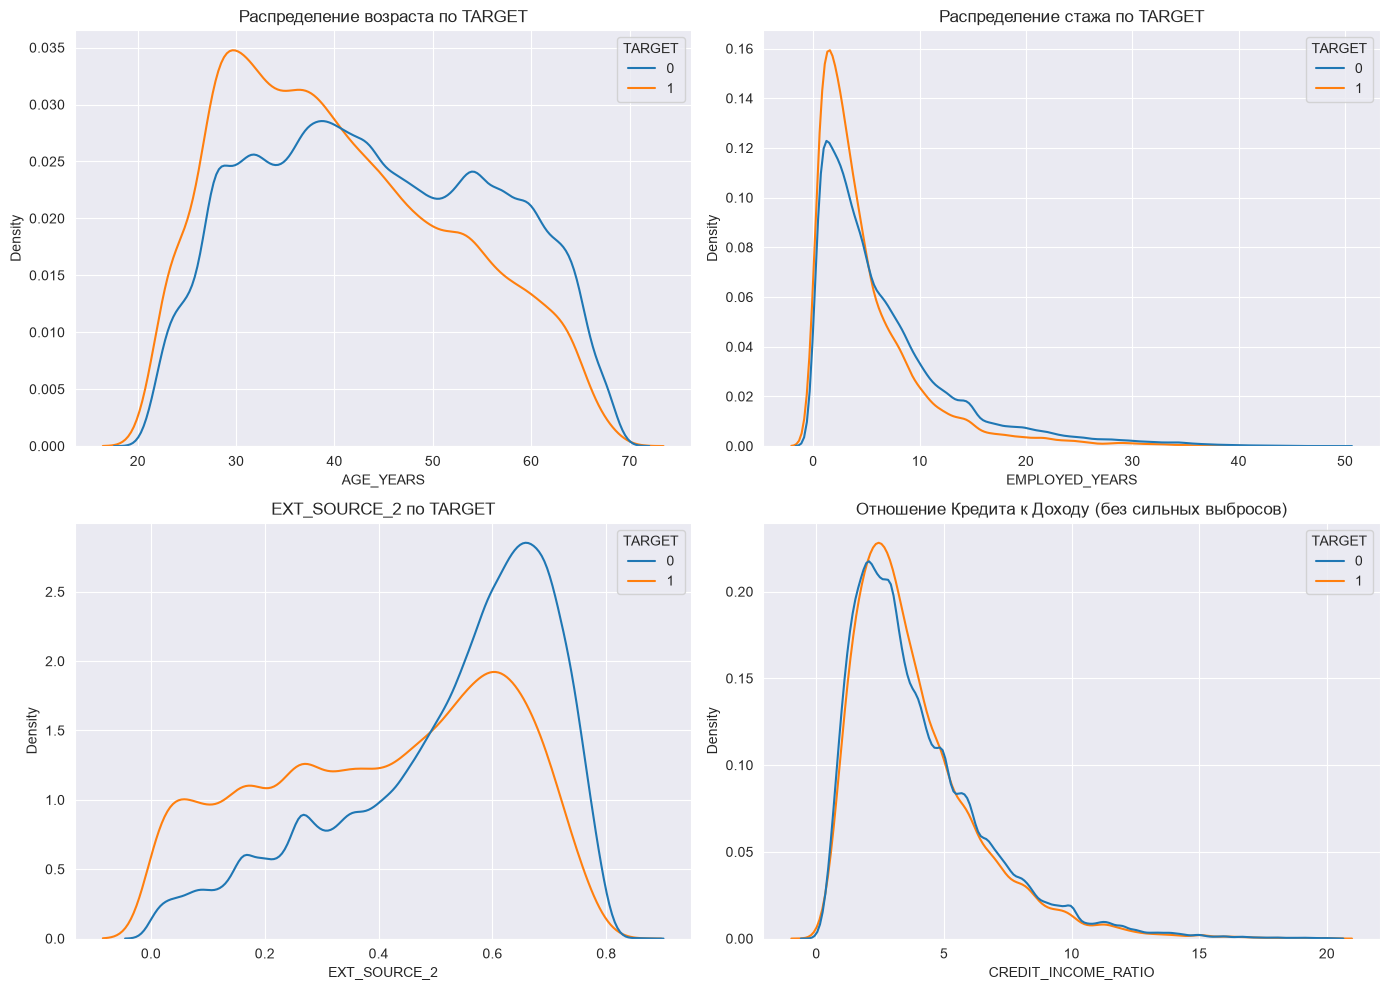

In [6]:
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(2, 2)

# 1. Возраст
sns.kdeplot(data=df, x='AGE_YEARS', hue='TARGET', common_norm=False, ax=axes[0,0])
axes[0,0].set_title('Распределение возраста по TARGET')

# 2. Стаж
sns.kdeplot(data=df, x='EMPLOYED_YEARS', hue='TARGET', common_norm=False, ax=axes[0,1])
axes[0,1].set_title('Распределение стажа по TARGET')

# 3. EXT_SOURCE_2 (самый сильный обычно)
sns.kdeplot(data=df, x='EXT_SOURCE_2', hue='TARGET', common_norm=False, ax=axes[1,0])
axes[1,0].set_title('EXT_SOURCE_2 по TARGET')

# 4. CREDIT_INCOME_RATIO
sns.kdeplot(data=df[df['CREDIT_INCOME_RATIO'] < 20], x='CREDIT_INCOME_RATIO', hue='TARGET', common_norm=False, ax=axes[1,1])
axes[1,1].set_title('Отношение Кредита к Доходу (без сильных выбросов)')

plt.tight_layout()
plt.show()

In [7]:
# Средний TARGET в зависимости от возраста (бины)
df['AGE_BIN'] = pd.cut(df['AGE_YEARS'], bins=[20, 30, 40, 50, 60, 70])
print(df.groupby('AGE_BIN', observed=True)['TARGET'].agg(['mean', 'count']))

# Средний TARGET в зависимости от стажа
df['EMP_BIN'] = pd.cut(df['EMPLOYED_YEARS'], bins=[-0.1, 1, 3, 6, 10, 50])
print(df.groupby('EMP_BIN', observed=True)['TARGET'].agg(['mean', 'count']))

              mean  count
AGE_BIN                  
(20, 30]  0.114320  45530
(30, 40]  0.095834  82413
(40, 50]  0.076335  76479
(50, 60]  0.061031  68080
(60, 70]  0.049387  35009
                  mean  count
EMP_BIN                      
(-0.1, 1.0]   0.109677  29833
(1.0, 3.0]    0.110719  61200
(3.0, 6.0]    0.092149  62334
(6.0, 10.0]   0.070924  48249
(10.0, 50.0]  0.051879  50521


In [8]:
# =============================================
# 1. Обработка пропусков (простая стратегия)
# =============================================

# Числовые признаки — заполняем медианой
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'TARGET']

for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Категориальные — заполняем модой + отдельная категория для редких
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df[col] = df[col].fillna('Missing')

# =============================================
# 2. Кодирование категориальных признаков
# =============================================

# Для дерева (LightGBM/CatBoost) лучше Label Encoding или нативный categorical
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Пропуски после обработки:", df.isnull().sum().sum())
print("Размер данных:", df.shape)
print("\nПример данных:")
display(df[['TARGET', 'AGE_YEARS', 'EMPLOYED_YEARS', 'EXT_SOURCE_2', 'CREDIT_INCOME_RATIO',
            'CODE_GENDER', 'NAME_EDUCATION_TYPE']].head())

/var/folders/m9/qrthykks5d189t1s8cn6y4y40000gn/T/ipykernel_62343/2430719873.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


Пропуски после обработки: 55374
Размер данных: (307511, 133)

Пример данных:


,TARGET,AGE_YEARS,EMPLOYED_YEARS,EXT_SOURCE_2,CREDIT_INCOME_RATIO,CODE_GENDER,NAME_EDUCATION_TYPE
0,1,25.9,1.7,0.262949,2.007879,1,4
1,0,45.9,3.3,0.622246,4.790732,0,1
2,0,52.1,0.6,0.555912,1.999970,1,4
3,0,52.0,8.3,0.650442,2.316150,0,4
4,0,54.6,8.3,0.322738,4.222187,1,4


In [9]:
# Смотрим, где остались пропуски
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Оставшиеся пропуски:")
print(missing)
print("\nВсего пропусков:", missing.sum())

Оставшиеся пропуски:
EMP_BIN    55374
dtype: int64

Всего пропусков: 55374


In [10]:
# Удаляем временные бины
df = df.drop(columns=['AGE_BIN', 'EMP_BIN'], errors='ignore')

print("Пропуски после удаления бинов:", df.isnull().sum().sum())
print("Размер данных:", df.shape)

Пропуски после удаления бинов: 0
Размер данных: (307511, 131)


In [12]:
df.to_csv("/Users/ivan/Desktop/credit-default-risk/data/processed/train_processed.csv", index=False)